In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/Customer Churn.csv')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [ ]:
df['customerID'].duplicated().sum()

np.int64(0)

In [ ]:
def conv(value):
  if value == 1:
    return 'Yes'
  else:
      return 'No'

df ['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

#**Churn Count**

/tmp/ipython-input-323/2738506985.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'Churn', data = df, palette='flare')


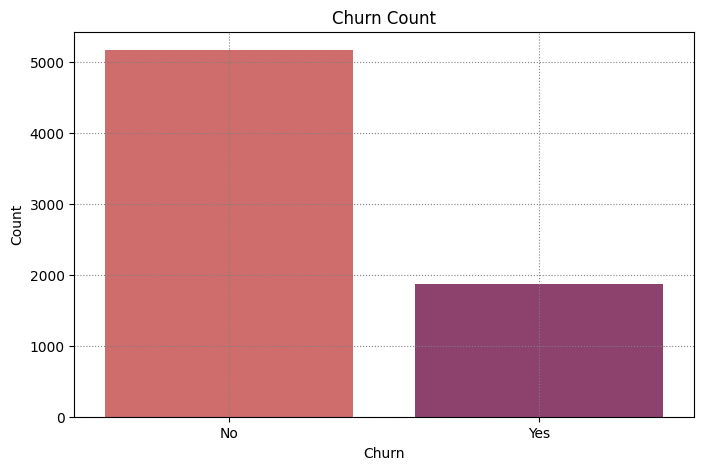

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x = 'Churn', data = df, palette='flare')
plt.title('Churn Count')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.grid(True, linestyle='dotted', color='grey')
plt.show()

#**Churn Count By Gender**

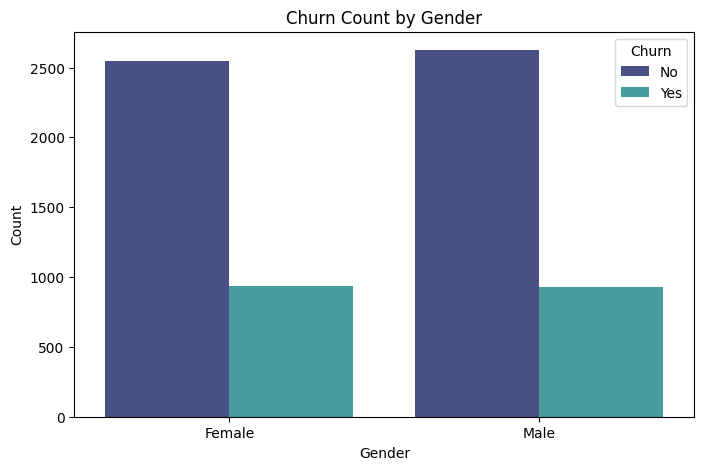

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'gender', data = df, hue='Churn', palette='mako')
plt.title('Churn Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

##**Top 10 Most Frequent Tenure Values**

/tmp/ipython-input-323/2218495986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tenure_counts.index, y=top_tenure_counts.values, palette='viridis')


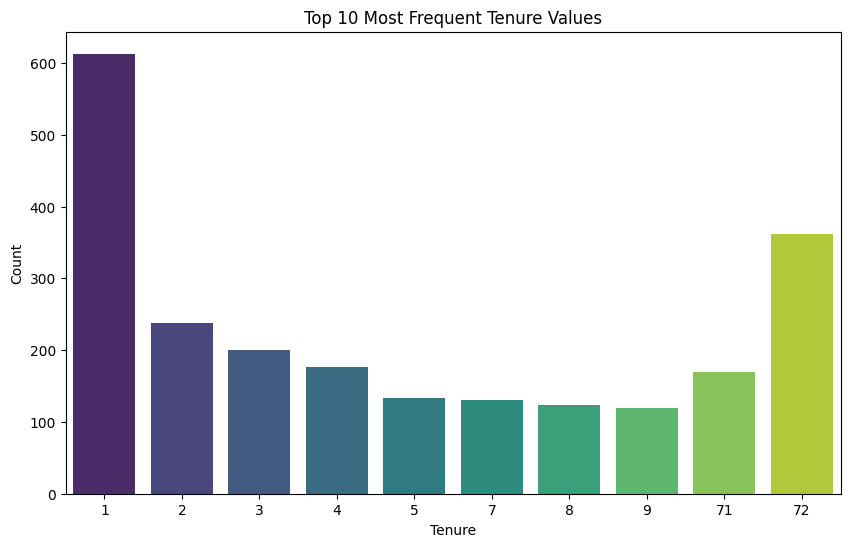

<Figure size 640x480 with 0 Axes>

In [84]:
top_tenure_counts = df['tenure'].value_counts().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_tenure_counts.index, y=top_tenure_counts.values, palette='viridis')
plt.title('Top 10 Most Frequent Tenure Values')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()
plt.savefig('top_tenure_counts.jpg')

In [50]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,No,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


#**Customer Payment Method**

/tmp/ipython-input-323/147034986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=customer_payment_method.index, x=customer_payment_method.values, palette='crest')


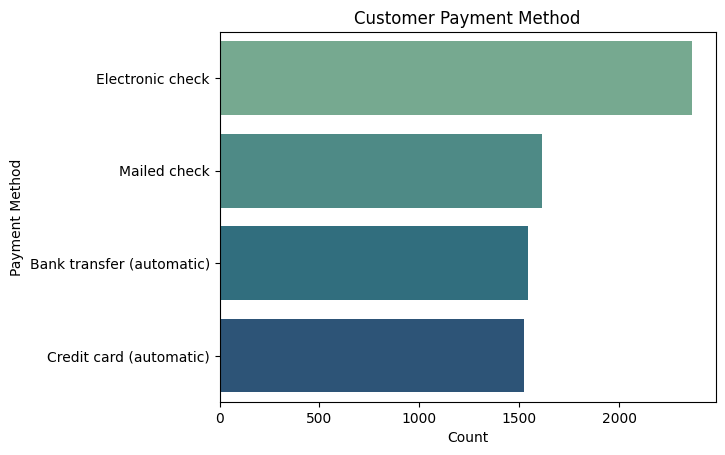

<Figure size 640x480 with 0 Axes>

In [83]:
customer_payment_method = df['PaymentMethod'].value_counts()
sns.barplot(y=customer_payment_method.index, x=customer_payment_method.values, palette='crest')
plt.title('Customer Payment Method')
plt.xlabel('Count')
plt.ylabel('Payment Method')
plt.show()
plt.savefig('customer_payment_method.png')

#**Top 10 Monthly Charges**

/tmp/ipython-input-323/1594914697.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_charges.index, y=monthly_charges.values, palette='magma')


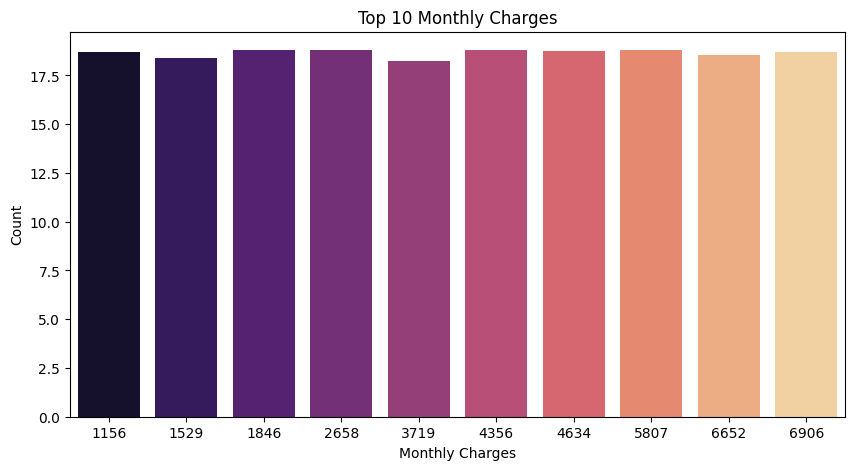

In [79]:
plt.figure(figsize=(10, 5))
monthly_charges = df['MonthlyCharges'].sort_values(ascending=True).head(10)
sns.barplot(x=monthly_charges.index, y=monthly_charges.values, palette='magma')
plt.title('Top 10 Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.savefig('Top 10 Monthly charges.png')